<a href="https://colab.research.google.com/github/Fathimaka04/ai-ml-workshop/blob/main/Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from zipfile import ZipFile
with ZipFile("emodetails.zip") as zip_ref:
  zip_ref.extractall("/content/emo")

In [32]:
import os

print(os.listdir("/content/"))


['.config', 'emo.zip', 'emotions', '.ipynb_checkpoints', 'sample_data']


In [31]:
image_folder = "/content/emo/emotions/emotions"

In [32]:
import os
import numpy as np
from PIL import Image

In [33]:
images = []
labels = []

In [34]:
for image_name in os.listdir(image_folder):

    image_path = os.path.join(image_folder, image_name)

    image = Image.open(image_path).convert("RGB")

    image = image.resize((128,128))

    image = np.array(image)

    image = image / 255.0

    images.append(image)

    if "happy" in image_name.lower():
          labels.append(0)
    elif "angry" in image_name.lower():
          labels.append(1)
    elif "sad" in image_name.lower():
          labels.append(2)
    elif "tensed" in image_name.lower():
          labels.append(3)

In [35]:
X = np.array(images)
y = np.array(labels)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(38, 128, 128, 3)
(10, 128, 128, 3)
(38,)
(10,)


In [38]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)

In [39]:
print(y_train[:5])

[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(4, activation="softmax")
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - accuracy: 0.3158 - loss: 4.6947 - val_accuracy: 0.7000 - val_loss: 1.5377
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.3158 - loss: 1.6529 - val_accuracy: 0.1000 - val_loss: 1.7013
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.3421 - loss: 1.3155 - val_accuracy: 0.1000 - val_loss: 1.5388
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.6053 - loss: 1.1935 - val_accuracy: 0.1000 - val_loss: 1.6714
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.5000 - loss: 1.0883 - val_accuracy: 0.1000 - val_loss: 1.6121
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.7105 - loss: 0.7468 - val_accuracy: 0.2000 - val_loss: 1.8090
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.8947 - loss: 0.5484 - val_accuracy: 0.1000 - val_loss: 2.3507
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.8947 - loss: 0.2644 - val_accuracy: 0.2000 - val_loss:

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
model.summary()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2000 - loss: 2.7264
Test Loss: 2.7264416217803955
Test Accuracy: 0.20000000298023224


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,178,510 (84.60 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,785,674 (56.40 MB)

In [44]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [45]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test, axis=1)

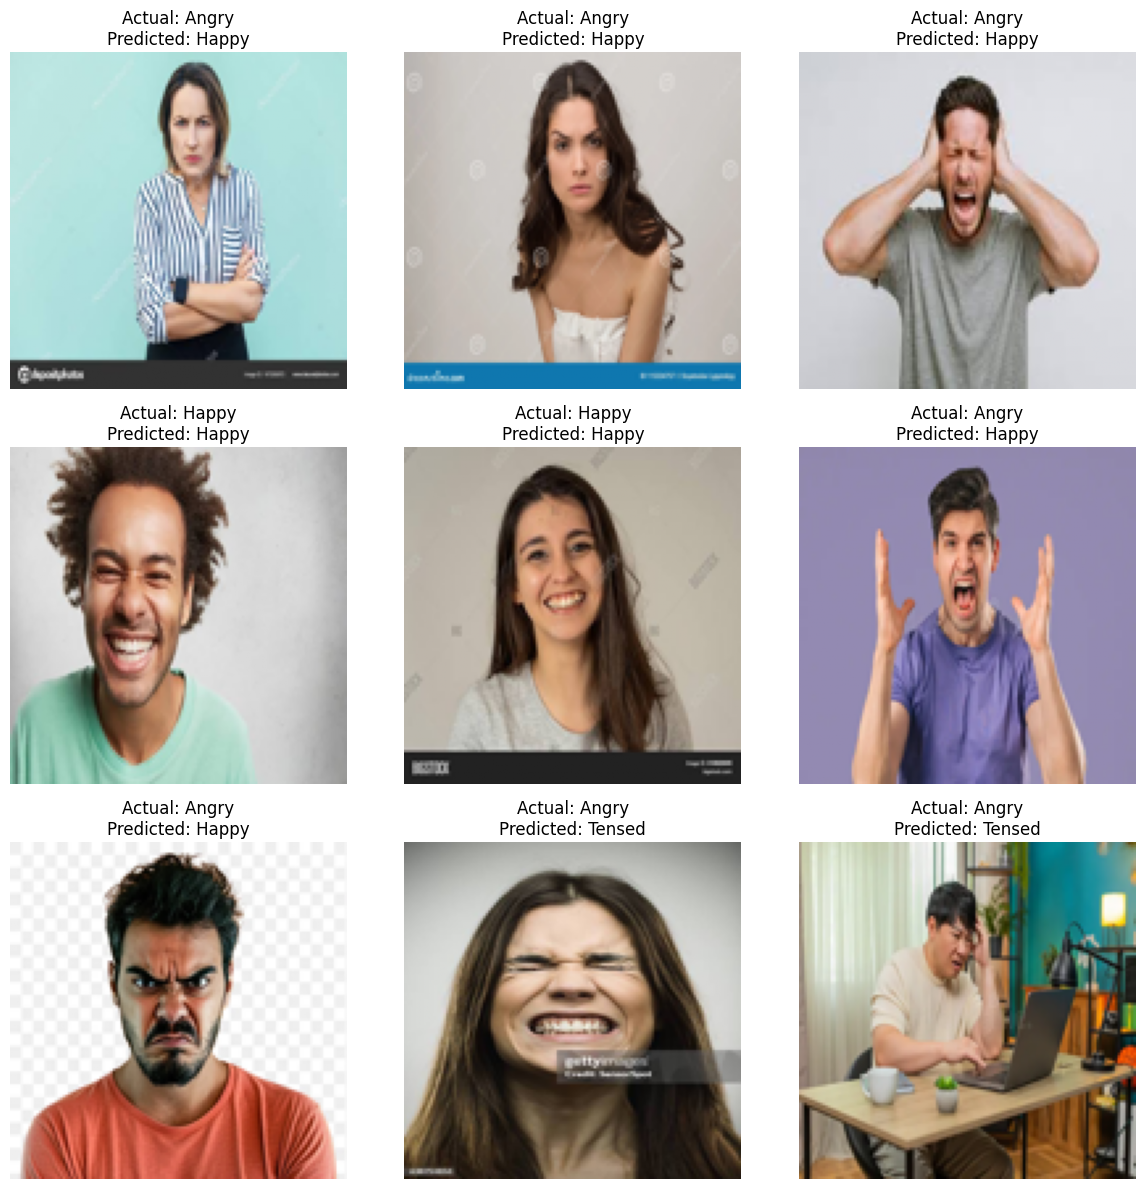

In [46]:
emotion_names = ["Happy", "Angry", "Sad", "Tensed"]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(min(len(X_test), 9)):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(
        f"Actual: {emotion_names[true_labels[i]]}\n"
        f"Predicted: {emotion_names[predicted_labels[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

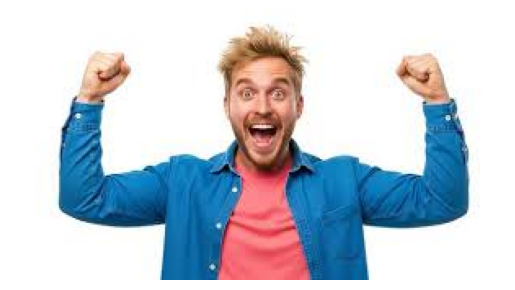

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Emotion: Happy


In [47]:
image=Image.open("/content/happy.jpg").convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()
image = image.resize((128,128))
image = np.array(image)
image = image / 255.0
image = np.expand_dims(image, axis=0)
prediction = model.predict(image)
predicted_class = np.argmax(prediction)
predicted_class = np.argmax(prediction)
emotion_names = ["Happy", "Angry", "Sad", "Tensed"]
print("Predicted Emotion:", emotion_names[predicted_class])

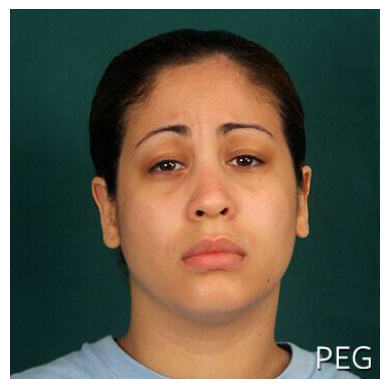

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Emotion: Happy


In [48]:
image=Image.open("/content/sad.jpg").convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()
image = image.resize((128,128))
image = np.array(image)
image = image / 255.0
image = np.expand_dims(image, axis=0)
prediction = model.predict(image)
predicted_class = np.argmax(prediction)
predicted_class = np.argmax(prediction)
emotion_names = ["Happy", "Angry", "Sad", "Tensed"]
print("Predicted Emotion:", emotion_names[predicted_class])

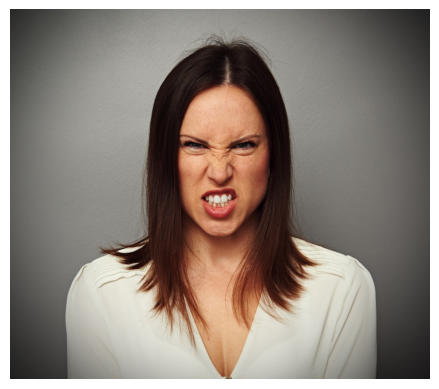

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Emotion: Angry


In [49]:
image=Image.open("/content/angry.jpg").convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()
image = image.resize((128,128))
image = np.array(image)
image = image / 255.0
image = np.expand_dims(image, axis=0)
prediction = model.predict(image)
predicted_class = np.argmax(prediction)
predicted_class = np.argmax(prediction)
emotion_names = ["Happy", "Angry", "Sad", "Tensed"]
print("Predicted Emotion:", emotion_names[predicted_class])